# Лабораторная работа №5.1

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Реализация алгоритма Policy Iteration

In [ ]:
# Импорт необходимых библиотек для выполнения лабораторной работы

try:
    import gym
except ImportError:
    !pip install gym==0.26.2
    import gym

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
import time

print("Библиотеки успешно импортированы")
print("Версия Gym:", gym.__version__)
print("Версия NumPy:", np.__version__)

Библиотеки успешно импортированы
Версия Gym: 0.25.2
Версия NumPy: 2.0.2


In [ ]:
# Установка совместимых версий библиотек для корректной работы среды Gym

!pip install gym==0.26.2 numpy==1.23.5 -q

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 20.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 96.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
# Создание среды Taxi-v3 и вывод основных характеристик среды

env = gym.make("Taxi-v3")

print("Среда:", "Taxi-v3")
print("Пространство состояний:")
pprint(env.observation_space)

print("\nПространство действий:")
pprint(env.action_space)

print("\nДиапазон наград:")
pprint(env.reward_range)

print("\nКоличество состояний:", env.observation_space.n)
print("Количество действий:", env.action_space.n)

state = env.reset()
if isinstance(state, tuple):
    state = state[0]

print("\nНачальное состояние:", state)
print("\nПример отображения среды:")
env.render()

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:49: DeprecationWarning: WARN: You are calling render method, but you didn't specified the argument render_mode at environment initialization. To maintain backward compatibility, the environment will render in human mode.
If you want to render in human mode, initialize the environment in this way: gym.make('EnvName', render_mode='human') and don

Среда: Taxi-v3
Пространство состояний:
Discrete(500)

Пространство действий:
Discrete(6)

Диапазон наград:
(-inf, inf)

Количество состояний: 500
Количество действий: 6

Начальное состояние: 322

Пример отображения среды:


In [ ]:
# Вывод информации о переходах и наградах для выбранного состояния и действия

state = 54
action = 0

print("Выбранное состояние:", state)
print("Выбранное действие:", action)

print("\nВероятности переходов для выбранного состояния и действия:")
pprint(env.P[state][action])

print("\nВсе возможные действия для выбранного состояния:")
pprint(env.P[state])

Выбранное состояние: 54
Выбранное действие: 0

Вероятности переходов для выбранного состояния и действия:
[(1.0, 154, -1, False)]

Все возможные действия для выбранного состояния:
{0: [(1.0, 154, -1, False)],
 1: [(1.0, 54, -1, False)],
 2: [(1.0, 74, -1, False)],
 3: [(1.0, 54, -1, False)],
 4: [(1.0, 54, -10, False)],
 5: [(1.0, 54, -10, False)]}


In [ ]:
# Создание класса агента и инициализация начальной стратегии

class PolicyIterationAgent:
    '''
    Класс агента, реализующего алгоритм Policy Iteration
    для дискретной среды Taxi-v3.
    '''
    def __init__(self, env, gamma=0.99, theta=1e-8, max_iterations=1000):
        self.env = env

        # Количество состояний и действий
        self.observation_dim = env.observation_space.n
        self.action_dim = env.action_space.n

        # Массив доступных действий
        self.actions_variants = np.arange(self.action_dim)

        # Начальная стратегия: равномерный выбор каждого действия
        self.policy_probs = np.full(
            (self.observation_dim, self.action_dim),
            1 / self.action_dim
        )

        # Начальные значения функции ценности состояний
        self.state_values = np.zeros(self.observation_dim)

        # Параметры алгоритма
        self.gamma = gamma
        self.theta = theta
        self.max_iterations = max_iterations

        # История изменения функции ценности
        self.evaluation_history = []
        self.policy_changes_history = []


    def print_info(self):
        '''
        Вывод основной информации об агенте.
        '''
        print("Количество состояний:", self.observation_dim)
        print("Количество действий:", self.action_dim)
        print("Коэффициент дисконтирования gamma:", self.gamma)
        print("Порог сходимости theta:", self.theta)
        print("Максимальное количество итераций:", self.max_iterations)
        print("Размер матрицы стратегии:", self.policy_probs.shape)
        print("Размер вектора ценностей:", self.state_values.shape)


    def print_policy_fragment(self, count=10):
        '''
        Вывод фрагмента начальной стратегии.
        '''
        print("Фрагмент стратегии для первых", count, "состояний:")
        pprint(self.policy_probs[:count])


agent = PolicyIterationAgent(env)

agent.print_info()
print()
agent.print_policy_fragment(10)

Количество состояний: 500
Количество действий: 6
Коэффициент дисконтирования gamma: 0.99
Порог сходимости theta: 1e-08
Максимальное количество итераций: 1000
Размер матрицы стратегии: (500, 6)
Размер вектора ценностей: (500,)

Фрагмент стратегии для первых 10 состояний:
array([[0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.1666666

In [ ]:
# Реализация этапа оценивания стратегии Policy Evaluation

class PolicyIterationAgent:
    '''
    Класс агента, реализующего алгоритм Policy Iteration
    для дискретной среды Taxi-v3.
    '''
    def __init__(self, env, gamma=0.99, theta=1e-8, max_iterations=1000):
        self.env = env

        self.observation_dim = env.observation_space.n
        self.action_dim = env.action_space.n

        self.actions_variants = np.arange(self.action_dim)

        self.policy_probs = np.full(
            (self.observation_dim, self.action_dim),
            1 / self.action_dim
        )

        self.state_values = np.zeros(self.observation_dim)

        self.gamma = gamma
        self.theta = theta
        self.max_iterations = max_iterations

        self.evaluation_history = []
        self.policy_changes_history = []


    def print_info(self):
        '''
        Вывод основной информации об агенте.
        '''
        print("Количество состояний:", self.observation_dim)
        print("Количество действий:", self.action_dim)
        print("Коэффициент дисконтирования gamma:", self.gamma)
        print("Порог сходимости theta:", self.theta)
        print("Максимальное количество итераций:", self.max_iterations)
        print("Размер матрицы стратегии:", self.policy_probs.shape)
        print("Размер вектора ценностей:", self.state_values.shape)


    def print_policy_fragment(self, count=10):
        '''
        Вывод фрагмента стратегии.
        '''
        print("Фрагмент стратегии для первых", count, "состояний:")
        pprint(self.policy_probs[:count])


    def policy_evaluation(self):
        '''
        Оценивание текущей стратегии.
        '''
        self.evaluation_history = []

        for iteration in range(self.max_iterations):
            new_state_values = np.zeros(self.observation_dim)

            for state in range(self.observation_dim):
                state_value = 0

                for action in range(self.action_dim):
                    action_probability = self.policy_probs[state][action]
                    transition_value = 0

                    for probability, next_state, reward, is_terminal in self.env.P[state][action]:
                        transition_value += probability * (
                            reward + self.gamma * self.state_values[next_state]
                        )

                    state_value += action_probability * transition_value

                new_state_values[state] = state_value

            difference = np.max(np.abs(new_state_values - self.state_values))
            self.evaluation_history.append(difference)
            self.state_values = new_state_values

            if difference < self.theta:
                print("Оценивание стратегии завершено за", iteration + 1, "итераций")
                print("Максимальное изменение функции ценности:", difference)
                break

        return self.state_values


agent = PolicyIterationAgent(env)
state_values = agent.policy_evaluation()

print("\nФрагмент функции ценности для первых 20 состояний:")
print(state_values[:20])


Фрагмент функции ценности для первых 20 состояний:
[-364.93138404 -377.77869537 -375.36017601 -377.98693597 -395.64888943
 -393.28309066 -395.71344445 -395.21780063 -389.91514023 -390.85080962
 -384.16428272 -390.90760485 -396.17405944 -395.77070384 -396.22107692
 -393.84974505 -354.66893319 -374.60971144 -370.85583507 -374.93293113]


In [ ]:
# Реализация этапа улучшения стратегии Policy Improvement

def policy_improvement_for_agent(agent):
    '''
    Улучшение стратегии на основе текущей функции ценности состояний.
    '''
    q_values = np.zeros((agent.observation_dim, agent.action_dim))
    improved_policy = np.zeros((agent.observation_dim, agent.action_dim))

    for state in range(agent.observation_dim):
        for action in range(agent.action_dim):
            for probability, next_state, reward, is_terminal in agent.env.P[state][action]:
                q_values[state, action] += probability * (
                    reward + agent.gamma * agent.state_values[next_state]
                )

        best_action_value = np.max(q_values[state])
        best_actions = np.where(q_values[state] == best_action_value)[0]

        for best_action in best_actions:
            improved_policy[state, best_action] = 1 / len(best_actions)

    policy_changes = np.sum(agent.policy_probs != improved_policy)
    agent.policy_probs = improved_policy
    agent.policy_changes_history.append(policy_changes)

    print("Количество измененных элементов стратегии:", policy_changes)

    return improved_policy, q_values


improved_policy, q_values = policy_improvement_for_agent(agent)

print("\nФрагмент улучшенной стратегии для первых 20 состояний:")
print(improved_policy[:20])

print("\nФрагмент Q-значений для первых 10 состояний:")
print(q_values[:10])

Количество измененных элементов стратегии: 3000

Фрагмент улучшенной стратегии для первых 20 состояний:
[[0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1. ]
 [0.  0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0.  0. ]]

Фрагмент Q-значений для первых 10 состояний:
[[-372.27418989 -362.2820702  -369.34666215 -362.2820702  -352.12224386
  -371.2820702 ]
 [-381.33067801 -375.00090842 -379.47615915 -375.00090842 -371.86361432
  -384.00090842]
 [-379.62578743 -372.60657425 -377.56927282 -372.60657425 -368.14727671
  -381.60657425]
 [-381.47747259 -375.20706661 -379.6403463

In [ ]:
# Реализация полного алгоритма Policy Iteration

def run_policy_iteration(agent):
    '''
    Полная реализация алгоритма Policy Iteration.
    На каждой итерации выполняется оценивание и улучшение стратегии.
    '''
    start_time = time.time()

    for iteration in range(agent.max_iterations):
        old_policy = agent.policy_probs.copy()

        agent.policy_evaluation()
        improved_policy, q_values = policy_improvement_for_agent(agent)

        policy_is_stable = np.array_equal(old_policy, improved_policy)

        print("Итерация:", iteration + 1)
        print("Стабильность стратегии:", policy_is_stable)
        print("-" * 50)

        if policy_is_stable:
            execution_time = time.time() - start_time
            print("Алгоритм Policy Iteration завершен")
            print("Количество итераций:", iteration + 1)
            print("Время выполнения:", execution_time)
            return iteration + 1, execution_time, q_values

    execution_time = time.time() - start_time
    print("Достигнуто максимальное количество итераций")
    print("Время выполнения:", execution_time)
    return agent.max_iterations, execution_time, q_values


agent = PolicyIterationAgent(env)
iterations_count, execution_time, final_q_values = run_policy_iteration(agent)

print("\nФрагмент итоговой стратегии для первых 20 состояний:")
print(agent.policy_probs[:20])

print("\nФрагмент итоговой функции ценности для первых 20 состояний:")
print(agent.state_values[:20])

Количество измененных элементов стратегии: 3000
Итерация: 1
Стабильность стратегии: False
--------------------------------------------------
Количество измененных элементов стратегии: 1342
Итерация: 2
Стабильность стратегии: False
--------------------------------------------------
Количество измененных элементов стратегии: 1229
Итерация: 3
Стабильность стратегии: False
--------------------------------------------------
Количество измененных элементов стратегии: 306
Итерация: 4
Стабильность стратегии: False
--------------------------------------------------
Оценивание стратегии завершено за 12 итераций
Максимальное изменение функции ценности: 1.7053025658242404e-12
Количество измененных элементов стратегии: 18
Итерация: 5
Стабильность стратегии: False
--------------------------------------------------
Оценивание стратегии завершено за 1 итераций
Максимальное изменение функции ценности: 1.7053025658242404e-12
Количество измененных элементов стратегии: 0
Итерация: 6
Стабильность стратегии

In [ ]:
# Формирование итоговой детерминированной стратегии и расшифровка действий

action_names = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff"
}

deterministic_policy = np.argmax(agent.policy_probs, axis=1)

print("Фрагмент итоговой детерминированной стратегии для первых 30 состояний:")
for state in range(30):
    action = deterministic_policy[state]
    print(
        "Состояние:",
        state,
        "| Действие:",
        action,
        "| Название действия:",
        action_names[action]
    )

Фрагмент итоговой детерминированной стратегии для первых 30 состояний:
Состояние: 0 | Действие: 4 | Название действия: Pickup
Состояние: 1 | Действие: 4 | Название действия: Pickup
Состояние: 2 | Действие: 4 | Название действия: Pickup
Состояние: 3 | Действие: 4 | Название действия: Pickup
Состояние: 4 | Действие: 0 | Название действия: South
Состояние: 5 | Действие: 0 | Название действия: South
Состояние: 6 | Действие: 0 | Название действия: South
Состояние: 7 | Действие: 0 | Название действия: South
Состояние: 8 | Действие: 0 | Название действия: South
Состояние: 9 | Действие: 0 | Название действия: South
Состояние: 10 | Действие: 0 | Название действия: South
Состояние: 11 | Действие: 0 | Название действия: South
Состояние: 12 | Действие: 0 | Название действия: South
Состояние: 13 | Действие: 0 | Название действия: South
Состояние: 14 | Действие: 0 | Название действия: South
Состояние: 15 | Действие: 0 | Название действия: South
Состояние: 16 | Действие: 5 | Название действия: Dropof

In [ ]:
# Исправление совместимости Gym с NumPy 2.0

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

In [ ]:
# Проверка работы обученного агента в среде Taxi-v3

def evaluate_trained_agent(env, policy, episodes_count=20, max_steps=200):
    '''
    Проверка качества обученной стратегии на нескольких эпизодах.
    '''
    rewards = []
    steps_list = []
    successful_episodes = 0

    for episode in range(episodes_count):
        reset_result = env.reset()
        state = reset_result[0] if isinstance(reset_result, tuple) else reset_result

        total_reward = 0
        steps = 0
        done = False
        truncated = False

        while not (done or truncated) and steps < max_steps:
            action = policy[state]
            step_result = env.step(action)

            if len(step_result) == 5:
                next_state, reward, done, truncated, info = step_result
            else:
                next_state, reward, done, info = step_result
                truncated = False

            total_reward += reward
            state = next_state
            steps += 1

        if total_reward > 0:
            successful_episodes += 1

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list, successful_episodes


rewards, steps_list, successful_episodes = evaluate_trained_agent(
    env,
    deterministic_policy,
    episodes_count=20
)

print("Количество тестовых эпизодов:", len(rewards))
print("Количество успешных эпизодов:", successful_episodes)
print("Средняя награда:", np.mean(rewards))
print("Минимальная награда:", np.min(rewards))
print("Максимальная награда:", np.max(rewards))
print("Среднее количество шагов:", np.mean(steps_list))

print("\nНаграды по эпизодам:")
print(rewards)

print("\nКоличество шагов по эпизодам:")
print(steps_list)

Количество тестовых эпизодов: 20
Количество успешных эпизодов: 20
Средняя награда: 7.95
Минимальная награда: 5
Максимальная награда: 14
Среднее количество шагов: 13.05

Награды по эпизодам:
[5, 11, 10, 5, 8, 14, 9, 5, 8, 6, 9, 12, 6, 5, 9, 7, 5, 8, 10, 7]

Количество шагов по эпизодам:
[16, 10, 11, 16, 13, 7, 12, 16, 13, 15, 12, 9, 15, 16, 12, 14, 16, 13, 11, 14]


In [ ]:
# Сравнение обученной стратегии со случайной стратегией

def evaluate_random_agent(env, episodes_count=20, max_steps=200):
    '''
    Проверка качества случайной стратегии на нескольких эпизодах.
    '''
    rewards = []
    steps_list = []
    successful_episodes = 0

    for episode in range(episodes_count):
        reset_result = env.reset()
        state = reset_result[0] if isinstance(reset_result, tuple) else reset_result

        total_reward = 0
        steps = 0
        done = False
        truncated = False

        while not (done or truncated) and steps < max_steps:
            action = env.action_space.sample()
            step_result = env.step(action)

            if len(step_result) == 5:
                next_state, reward, done, truncated, info = step_result
            else:
                next_state, reward, done, info = step_result
                truncated = False

            total_reward += reward
            state = next_state
            steps += 1

        if total_reward > 0:
            successful_episodes += 1

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list, successful_episodes


random_rewards, random_steps, random_successful = evaluate_random_agent(
    env,
    episodes_count=20
)

comparison_table = pd.DataFrame({
    "Стратегия": ["Случайная стратегия", "Стратегия Policy Iteration"],
    "Количество успешных эпизодов": [random_successful, successful_episodes],
    "Средняя награда": [np.mean(random_rewards), np.mean(rewards)],
    "Минимальная награда": [np.min(random_rewards), np.min(rewards)],
    "Максимальная награда": [np.max(random_rewards), np.max(rewards)],
    "Среднее количество шагов": [np.mean(random_steps), np.mean(steps_list)]
})

comparison_table

,Стратегия,Количество успешных эпизодов,Средняя награда,Минимальная награда,Максимальная награда,Среднее количество шагов
0,Случайная стратегия,0,-786.35,-938,-668,200.00
1,Стратегия Policy Iteration,20,7.95,5,14,13.05


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


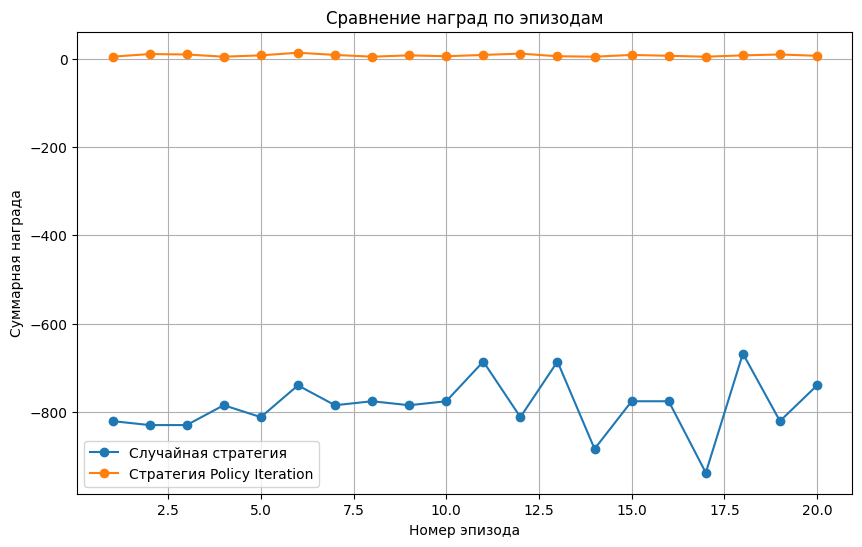

In [ ]:
# Построение графика сравнения наград по эпизодам

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(random_rewards) + 1),
    random_rewards,
    marker='o',
    label='Случайная стратегия'
)

plt.plot(
    range(1, len(rewards) + 1),
    rewards,
    marker='o',
    label='Стратегия Policy Iteration'
)

plt.title('Сравнение наград по эпизодам')
plt.xlabel('Номер эпизода')
plt.ylabel('Суммарная награда')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Формирование итоговой таблицы результатов лабораторной работы

final_results = pd.DataFrame({
    "Показатель": [
        "Среда",
        "Количество состояний",
        "Количество действий",
        "Коэффициент дисконтирования",
        "Порог сходимости",
        "Количество итераций Policy Iteration",
        "Время выполнения алгоритма",
        "Количество тестовых эпизодов",
        "Количество успешных эпизодов",
        "Средняя награда обученного агента",
        "Среднее количество шагов обученного агента"
    ],
    "Значение": [
        "Taxi-v3",
        env.observation_space.n,
        env.action_space.n,
        agent.gamma,
        agent.theta,
        iterations_count,
        execution_time,
        len(rewards),
        successful_episodes,
        np.mean(rewards),
        np.mean(steps_list)
    ]
})

final_results

,Показатель,Значение
0,Среда,Taxi-v3
1,Количество состояний,500
2,Количество действий,6
3,Коэффициент дисконтирования,0.99
4,Порог сходимости,0.0
5,Количество итераций Policy Iteration,6
6,Время выполнения алгоритма,25.898879
7,Количество тестовых эпизодов,20
8,Количество успешных эпизодов,20
9,Средняя награда обученного агента,7.95


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
